# MobileNetV3 매력도 회귀 모델 학습

`labels_combined_1to5.xlsx`의 `전체` 시트(1~5점 통합 스케일)와 `images/` 폴더의 이미지를 이용해
MobileNetV3(torchvision, ImageNet 사전학습)를 회귀 모델로 파인튜닝합니다.

**학습 데이터셋**: `aihub`, `scut_fbp5500`만 사용합니다. `남자연예인`/`여자연예인`은
라벨 로드 단계에서 `EXCLUDE_DATASETS`로 제외됩니다.

**시작 전 준비 (로컬 PC에서)**
1. `image_attractive_visionProject-main` 폴더 전체를 zip으로 압축합니다.
2. 압축 파일을 Google Drive에 업로드합니다 (예: `MyDrive/image_attractive_visionProject-main.zip`).
3. 이 노트북을 Colab에서 열고, 런타임 유형을 GPU로 설정합니다 (런타임 > 런타임 유형 변경 > GPU).
4. 아래 '설정' 셀의 `DRIVE_ZIP_PATH`를 실제 업로드 경로로 맞춰줍니다.

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 설정

In [23]:
import os

DRIVE_ZIP_PATH = "/content/my_data.zip"   # 파일 위치에 맞게 수정 (Drive면 /content/drive/MyDrive/my_data.zip)
EXTRACT_DIR = "/content/data_extracted"
PROJECT_DIR = os.path.join(EXTRACT_DIR, "data")  # zip 안 최상위 폴더명은 여전히 "data"라고 가정

IMAGES_DIR = os.path.join(PROJECT_DIR, "images")
LABELS_XLSX = os.path.join(PROJECT_DIR, "labels_combined_1to5.xlsx")

CKPT_PATH = "/content/mobilenetv3_regression_best.pt"
FINAL_MODEL_PATH = "/content/drive/MyDrive/mobilenetv3_attractiveness_regression.pt"

print("LABELS_XLSX =", LABELS_XLSX)

LABELS_XLSX = /content/data_extracted/data/labels_combined_1to5.xlsx


In [24]:
import zipfile

if not os.path.exists(PROJECT_DIR):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print("압축 해제 완료")
else:
    print("이미 압축 해제되어 있음")

압축 해제 완료


In [25]:
!pip install -q openpyxl scikit-learn scipy

In [26]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 라벨 로드 및 이미지 경로 매핑

In [27]:
df = pd.read_excel(LABELS_XLSX, sheet_name="전체")

# 학습에서 제외할 데이터셋 (연예인 사진 미사용)
EXCLUDE_DATASETS = ["남자연예인", "여자연예인"]
print("제외 전 라벨 수:", len(df))
df = df[~df["dataset"].isin(EXCLUDE_DATASETS)].reset_index(drop=True)
print("제외 후 라벨 수:", len(df), "(사용 데이터셋:", sorted(df["dataset"].unique()), ")")

df["filepath"] = df.apply(lambda r: os.path.join(IMAGES_DIR, r["dataset"], r["filename"]), axis=1)
df["exists"] = df["filepath"].apply(os.path.exists)
print("파일이 존재하지 않는 행 수:", (~df["exists"]).sum())

df = df[df["exists"]].reset_index(drop=True)
df["score"] = df["score"].astype(float)
df[["dataset", "filename", "score"]].head()

제외 전 라벨 수: 5182
제외 후 라벨 수: 4930 (사용 데이터셋: ['5_female', '5_male', 'aihub', 'scut_fbp5500'] )
파일이 존재하지 않는 행 수: 0


,dataset,filename,score
0,aihub,ID2303.png,2.0
1,aihub,ID2304.png,3.0
2,aihub,ID2305.png,2.0
3,aihub,ID2306.png,2.0
4,aihub,ID2307.png,2.0


## Train / Validation / Test 분할
데이터셋 종류로 층화 추출하여 8:1:1로 분할합니다.
(dataset+점수 조합으로 층화하면 표본이 적은 점수 구간에서 그룹 크기가 1이 되어 오류가 나므로 dataset만 사용합니다.)

In [28]:
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["dataset"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["dataset"]
)

print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))

train: 3944 val: 493 test: 493


## Dataset / DataLoader

In [29]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class AttractivenessDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        img = self.transform(img)
        score = torch.tensor(row["score"], dtype=torch.float32)
        return img, score

train_ds = AttractivenessDataset(train_df, train_transform)
val_ds = AttractivenessDataset(val_df, eval_transform)
test_ds = AttractivenessDataset(test_df, eval_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

## 모델 정의
MobileNetV3-Large의 분류기 마지막 레이어를 1개 출력(연속값)으로 교체합니다.

In [30]:
def build_model():
    model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, 1)
    return model

model = build_model().to(device)

# ---- 2단계 파인튜닝 설정 ----
STAGE1_EPOCHS = 5   # Stage 1: 백본 동결, head만 학습
STAGE1_LR = 1e-3
STAGE2_LR = 1e-5    # Stage 2: 전체 동결 해제 후 낮은 학습률로 재학습

# Stage 1 시작: 백본(features) 동결, classifier만 학습되게 설정
for p in model.features.parameters():
    p.requires_grad = False

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=STAGE1_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 66.4MB/s]


## 학습 / 평가 함수
2단계 파인튜닝으로 학습합니다: **Stage 1**은 백본을 동결하고 head(classifier)만 학습해 안정적으로 수렴시키고,
**Stage 2**는 전체를 동결 해제한 뒤 훨씬 낮은 학습률로 미세 조정합니다.

In [31]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    with torch.set_grad_enabled(train):
        for imgs, targets in loader:
            imgs = imgs.to(device)
            targets = targets.to(device).unsqueeze(1)
            if train:
                optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, targets)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            all_preds.extend(preds.detach().cpu().numpy().ravel())
            all_targets.extend(targets.detach().cpu().numpy().ravel())
    avg_loss = total_loss / len(loader.dataset)
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    mae = np.mean(np.abs(all_preds - all_targets))
    return avg_loss, mae, all_preds, all_targets

In [32]:
EPOCHS = 30       # Stage 2 최대 epoch 수
PATIENCE = 7
best_val_mae = float("inf")
history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

print("===== Stage 1: 백본 동결, head만 학습 =====")
for epoch in range(1, STAGE1_EPOCHS + 1):
    train_loss, train_mae, _, _ = run_epoch(train_loader, train=True)
    val_loss, val_mae, _, _ = run_epoch(val_loader, train=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    print(f"[Stage1 {epoch:02d}/{STAGE1_EPOCHS}] train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
          f"train_mae={train_mae:.4f} val_mae={val_mae:.4f}")

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"  -> best model saved (val_mae={val_mae:.4f})")

print("\n===== Stage 2: 전체 동결 해제, 낮은 학습률로 재학습 =====")
for p in model.parameters():
    p.requires_grad = True

optimizer = torch.optim.AdamW(model.parameters(), lr=STAGE2_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_mae, _, _ = run_epoch(train_loader, train=True)
    val_loss, val_mae, _, _ = run_epoch(val_loader, train=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    print(f"[Stage2 {epoch:02d}/{EPOCHS}] train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
          f"train_mae={train_mae:.4f} val_mae={val_mae:.4f}")

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        patience_counter = 0
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"  -> best model saved (val_mae={val_mae:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

===== Stage 1: 백본 동결, head만 학습 =====
[Stage1 01/5] train_loss=0.8730 val_loss=0.7210 train_mae=0.6978 val_mae=0.6734
  -> best model saved (val_mae=0.6734)
[Stage1 02/5] train_loss=0.4233 val_loss=0.5489 train_mae=0.5136 val_mae=0.5639
  -> best model saved (val_mae=0.5639)
[Stage1 03/5] train_loss=0.3809 val_loss=0.5604 train_mae=0.4878 val_mae=0.5596
  -> best model saved (val_mae=0.5596)
[Stage1 04/5] train_loss=0.3435 val_loss=0.5607 train_mae=0.4604 val_mae=0.5585
  -> best model saved (val_mae=0.5585)
[Stage1 05/5] train_loss=0.3113 val_loss=0.5194 train_mae=0.4416 val_mae=0.5448
  -> best model saved (val_mae=0.5448)

===== Stage 2: 전체 동결 해제, 낮은 학습률로 재학습 =====
[Stage2 01/30] train_loss=0.2534 val_loss=0.4946 train_mae=0.4009 val_mae=0.5219
  -> best model saved (val_mae=0.5219)
[Stage2 02/30] train_loss=0.2231 val_loss=0.4834 train_mae=0.3725 val_mae=0.5137
  -> best model saved (val_mae=0.5137)
[Stage2 03/30] train_loss=0.2136 val_loss=0.4678 train_mae=0.3668 val_mae=0.5073
  -

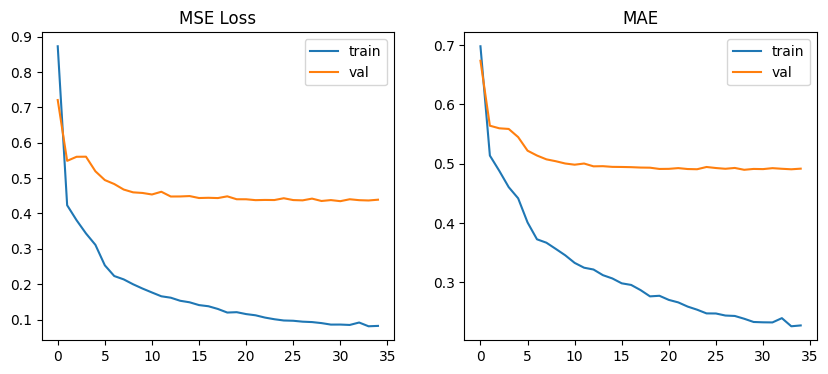

In [33]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.title("MSE Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_mae"], label="train")
plt.plot(history["val_mae"], label="val")
plt.title("MAE")
plt.legend()
plt.show()

## 테스트셋 평가

Test  MSE=0.3221  MAE=0.4446  RMSE=0.5675  Pearson r=0.8075


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

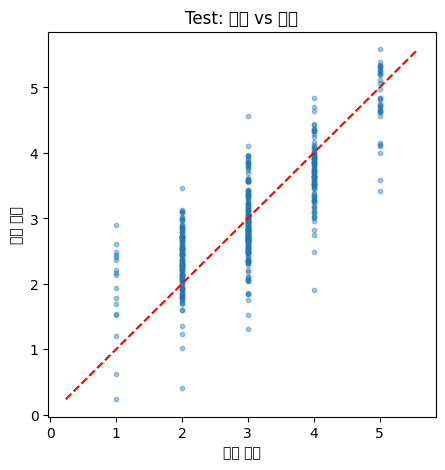

In [34]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
test_loss, test_mae, preds, targets = run_epoch(test_loader, train=False)
rmse = np.sqrt(np.mean((preds - targets) ** 2))
corr, _ = pearsonr(preds, targets)
print(f"Test  MSE={test_loss:.4f}  MAE={test_mae:.4f}  RMSE={rmse:.4f}  Pearson r={corr:.4f}")

plt.figure(figsize=(5, 5))
plt.scatter(targets, preds, alpha=0.4, s=10)
lims = [min(targets.min(), preds.min()), max(targets.max(), preds.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("실제 점수")
plt.ylabel("예측 점수")
plt.title("Test: 예측 vs 실제")
plt.show()

## 단일 이미지 추론 & 모델 저장

In [35]:
def predict_image(path):
    model.eval()
    img = Image.open(path).convert("RGB")
    x = eval_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        score = model(x).item()
    return score

# 사용 예시
sample_path = test_df.iloc[0]["filepath"]
print(sample_path, "-> 예측 점수:", predict_image(sample_path), "/ 실제:", test_df.iloc[0]["score"])

/content/data_extracted/data/images/scut_fbp5500/AM1216.jpg -> 예측 점수: 2.0370707511901855 / 실제: 2.0


## 예측 결과 갤러리 (사진 + 실제 라벨 + 예측 라벨)

/tmp/ipykernel_2016/810096388.py:14: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2016/810096388.py:14: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2016/810096388.py:14: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2016/810096388.py:14: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


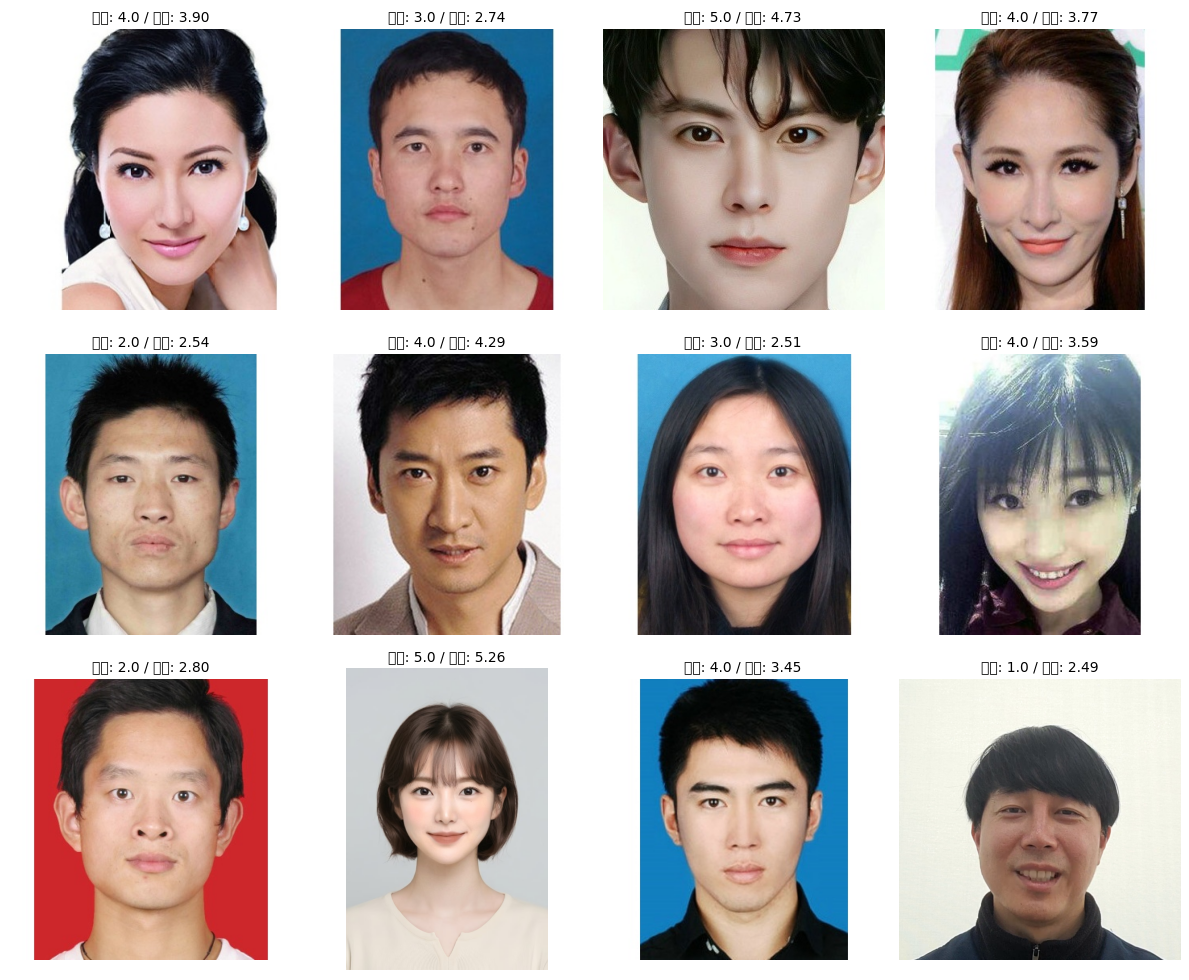

In [36]:
import math

def show_predictions_grid(dataframe, n=12, cols=4, seed=SEED):
    sample = dataframe.sample(n=min(n, len(dataframe)), random_state=seed).reset_index(drop=True)
    rows = math.ceil(len(sample) / cols)
    plt.figure(figsize=(cols * 3, rows * 3.3))
    for i, row in sample.iterrows():
        pred = predict_image(row["filepath"])
        img = Image.open(row["filepath"]).convert("RGB")
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"실제: {row['score']:.1f} / 예측: {pred:.2f}", fontsize=10)
    plt.tight_layout()
    plt.show()

# 테스트셋에서 무작위로 n장 뽑아 사진 + 실제 점수 + 예측 점수를 함께 표시
show_predictions_grid(test_df, n=12)

In [37]:
torch.save(model.state_dict(), FINAL_MODEL_PATH)
print("모델 저장 완료:", FINAL_MODEL_PATH)

모델 저장 완료: /content/drive/MyDrive/mobilenetv3_attractiveness_regression.pt


## 새로운 사진으로 직접 테스트하기
로컬 PC의 사진 파일을 업로드해서 학습된 모델로 매력도 점수를 예측해봅니다.

In [38]:
from google.colab import files
import math

uploaded = files.upload()  # 여러 장(예: 9장) 선택 가능
img_paths = list(uploaded.keys())

cols = 3
rows = math.ceil(len(img_paths) / cols)
plt.figure(figsize=(cols * 3.5, rows * 3.8))
for i, path in enumerate(img_paths):
    score = predict_image(path)
    img = Image.open(path).convert("RGB")
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{path}\n예측 점수: {score:.2f}", fontsize=10)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## 참고
- 이 노트북은 이미 2단계 파인튜닝(Stage 1: 백본 동결 → Stage 2: 낮은 학습률로 전체 재학습)을 적용합니다.
  `STAGE1_EPOCHS`, `STAGE1_LR`, `STAGE2_LR`은 "모델 정의" 셀에서 조정할 수 있습니다.
- 현재 `남자연예인`/`여자연예인` 데이터셋은 `EXCLUDE_DATASETS`에서 제외되어 학습에 사용되지 않습니다
  (`aihub`, `scut_fbp5500`만 사용). 다시 포함하려면 라벨 로드 셀의 `EXCLUDE_DATASETS`를 빈 리스트로 바꾸세요.
- 추가로 개선하고 싶다면: 얼굴 검출/크롭 전처리, 더 강한 데이터 증강, k-fold 교차검증 등을 고려해보세요.